In [7]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import seaborn as sns
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import sys
sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

## Compare Beta for 2 and 3 npix

In [8]:
beta_version = 'beta_v2'
gamma_version = 'gamma_v2'

In [9]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
# lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [10]:
product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

npix = 2

In [11]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.union_all()

In [12]:
dir_data = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV')
dir_file = os.path.join(dir_data,'uncorrected','quantiles_v1',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA_parameters = xr.open_dataset(dir_file)
MEVD_param = DATA_parameters.Mev_d.values

if product != 'GSMaP':
    dir_mask = os.path.join('..','..','output','Beta','beta_v1',f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_2.nc')
    DATA_mask = xr.open_dataset(dir_mask)
    DATA_mask = DATA_mask.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_min, lat_max))
    TMP = DATA_mask.BETA.values
    mask_NaN = np.isnan(TMP)
else:
    dir_mask = os.path.join('..','..','output','Beta','beta_v2',f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_3.nc')
    DATA_mask = xr.open_dataset(dir_mask)
    DATA_mask = DATA_mask.sel(
    lat=slice(DATA_parameters.lat.min(), DATA_parameters.lat.max()),
    lon=slice(DATA_parameters.lon.min(), DATA_parameters.lon.max()))
    TMP = DATA_mask.BETA.values
    mask_NaN = np.isnan(TMP)

MEVD_param[:,mask_NaN] = np.nan

In [13]:
dir_base = os.path.join('..','..','output','Beta',beta_version)

In [14]:
data_dir = os.path.join(dir_base,f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA = xr.open_dataset(data_dir)

# Cut with the final study area
DATA = DATA.sel(
    lat=slice(DATA_parameters.lat.min(), DATA_parameters.lat.max()),
    lon=slice(DATA_parameters.lon.min(), DATA_parameters.lon.max())
)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
Beta_2 = DATA.BETA.values


In [15]:
data_dir = os.path.join(dir_base,f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA = xr.open_dataset(data_dir)

# Cut with the final study area
DATA = DATA.sel(
    lat=slice(DATA_parameters.lat.min(), DATA_parameters.lat.max()),
    lon=slice(DATA_parameters.lon.min(), DATA_parameters.lon.max())
)

Beta_3 = DATA.BETA.values

In [16]:
Beta_2[mask_NaN] = np.nan
Beta_3[mask_NaN] = np.nan

In [17]:
BETA_min = np.max([np.nanmin(Beta_2), np.nanmin(Beta_3)])
BETA_min = np.round(BETA_min,2)
print(BETA_min)

BETA_max = np.max([np.nanmax(Beta_2), np.nanmax(Beta_3)])
BETA_max = np.round(BETA_max,2)
print(BETA_max)

1.0
1.11


In [ ]:
GAMMA_old = DATA_parameters.GAMMA.values
GAMMA_old[mask_NaN] = np.nan

# GAMMA_update = GAMMA_old - 0.05 # Only for test
GAMMA_update = np.copy(GAMMA_old)

GAMMA_update[mask_NaN] = np.nan

In [19]:
BETA_cmap = plt.cm.Spectral_r
BETA_levels = np.arange(BETA_min, BETA_max + 0.01, 0.01)
BETA_norm = mcolors.BoundaryNorm(boundaries=BETA_levels, ncolors=BETA_cmap.N, extend='max')

BETA_diff_cmap = plt.cm.bwr_r
BETA_diff_lvls = np.arange(-0.9, 0.9 + 0.05, 0.05)
BETA_diff_norm = mcolors.BoundaryNorm(boundaries=BETA_diff_lvls, ncolors=BETA_diff_cmap.N, extend='both')
BETA_diff_norm = None

Text(1.0, 1.0, 'IMERG')

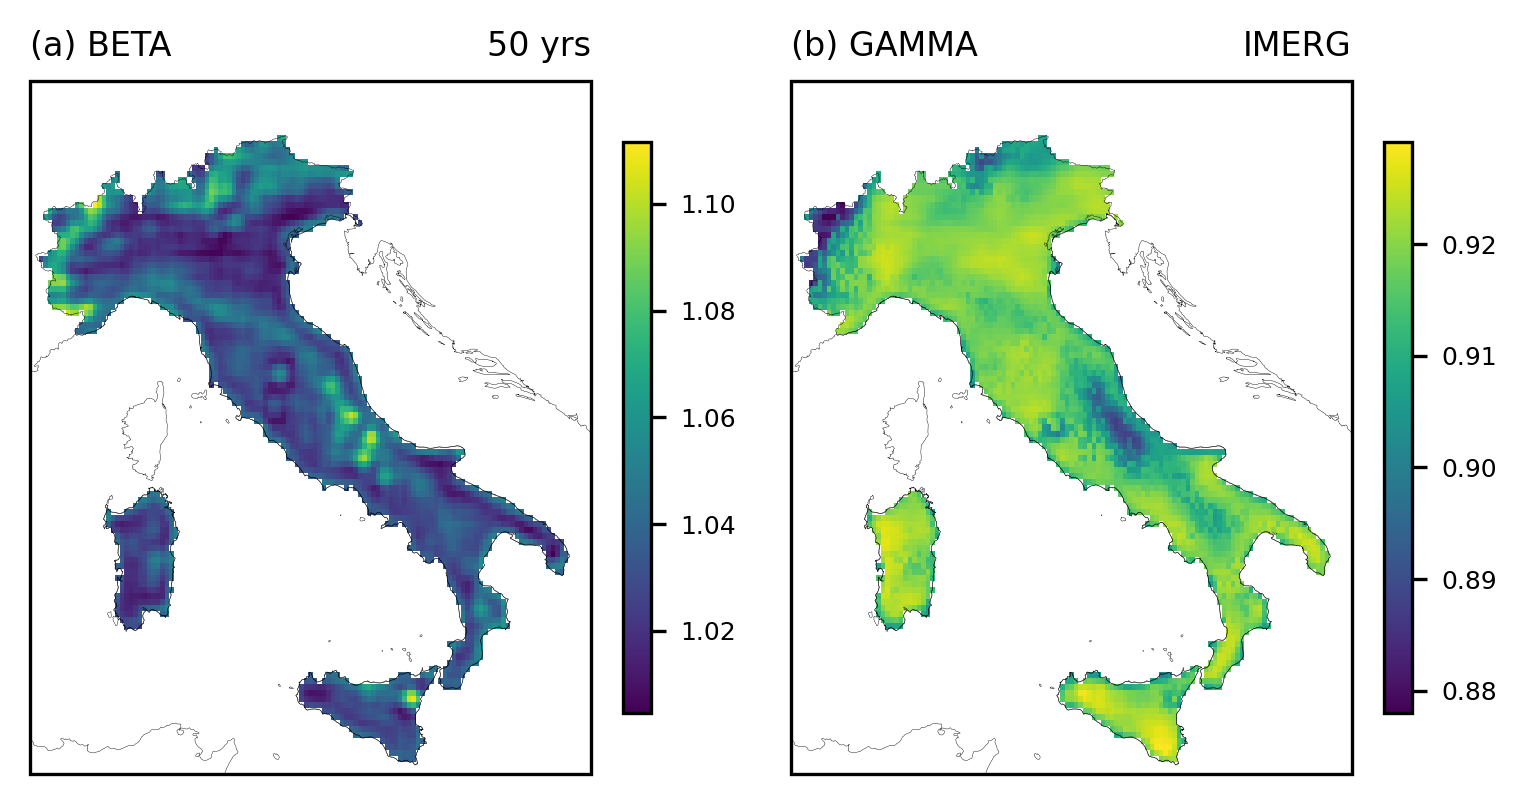

In [20]:
pos = 3

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Beta_3, norm=None, cmap=None)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) BETA', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA_update, norm=None, cmap=None)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) GAMMA', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

## Compute Quantiles

In [21]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

NYd = np.zeros(DATA_parameters.NYs.shape)
CYd = np.zeros(DATA_parameters.NYs.shape)
WYd = np.zeros(DATA_parameters.NYs.shape)
Mevd_B31 = np.zeros([6, len(lats), len(lons)])

for i in range(len(lats)):
    for j in range(len(lons)):

        Ns = DATA_parameters.NYs.values[:,i,j]
        Cs = DATA_parameters.CYs.values[:,i,j]
        Ws = DATA_parameters.WYs.values[:,i,j]

        bet = Beta_2[i,j]
        gam = GAMMA_update[i,j]

        if np.isnan(bet) == True:
            NYd[:,i,j] = np.nan
            CYd[:,i,j] = np.nan
            WYd[:,i,j] = np.nan
            Mevd_B31[:,i,j] = np.nan
        else:
            Nd, Cd, Wd = ART_downscale.down_wei_beta_alpha_update_v2(Ns, Cs, Ws, bet, gam)
            NYd[:,i,j] = Nd
            CYd[:,i,j] = Cd
            WYd[:,i,j] = Wd
            
            x0 = 5.0*np.mean(Cd)
            Mev_d_man, _ = ART_downscale.mev_quant_update(Fi, x0, Nd, Cd, Wd)
            Mevd_B31[:,i,j] = Mev_d_man


/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:782: RuntimeWarning: invalid value encountered in power
  mev0f = np.sum( ( 1-np.exp(-(y/C)**W ))**N) - nyears*pr


In [22]:
GAMMA_cmap = plt.cm.Spectral_r
GAMMA_levels = np.arange(0.72, 1.12, 0.02)
GAMMA_norm = mcolors.BoundaryNorm(boundaries=GAMMA_levels, ncolors=GAMMA_cmap.N, extend='max')

MEVD_cmap = plt.cm.Spectral_r
MEVD_levels = np.arange(20, 420, 20)
MEVD_norm = mcolors.BoundaryNorm(boundaries=MEVD_levels, ncolors=MEVD_cmap.N, extend='max')

DIFF_cmap = plt.cm.bwr_r
DIFF_levels = np.arange(-30, 35, 5)
DIFF_norm = mcolors.BoundaryNorm(boundaries=DIFF_levels, ncolors=DIFF_cmap.N, extend='both')

Text(0.0, 1.0, '(c) Quantiles Old - New')

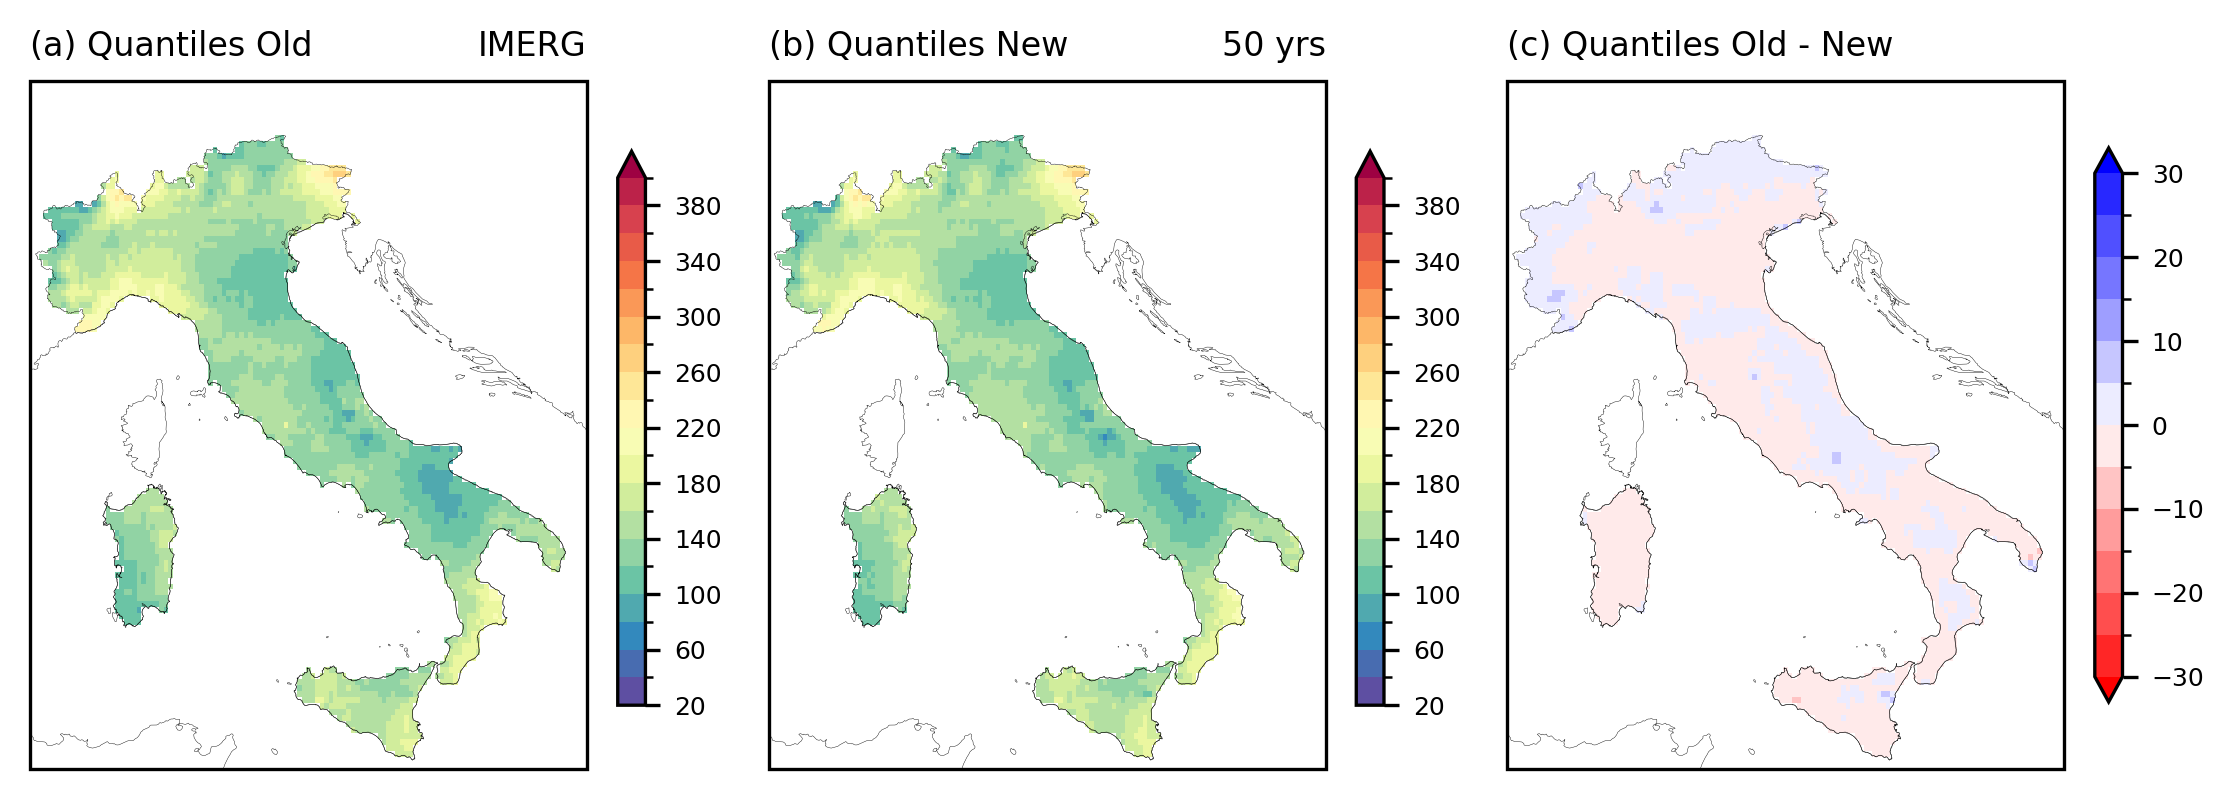

In [23]:
pos = 3

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_param[pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) Quantiles Old', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Mevd_B31[pos,:,:], norm=MEVD_norm, cmap=MEVD_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) Quantiles New', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_param[pos,:,:] - Mevd_B31[pos,:,:], norm=DIFF_norm, cmap=DIFF_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(c) Quantiles Old - New', fontsize=8, loc='left')

In [24]:
GAMMA_old_list =GAMMA_old[~np.isnan(GAMMA_old)]
GAMMA_list = GAMMA_update[~np.isnan(GAMMA_update)]

Text(0.5, 0, 'Beta values')

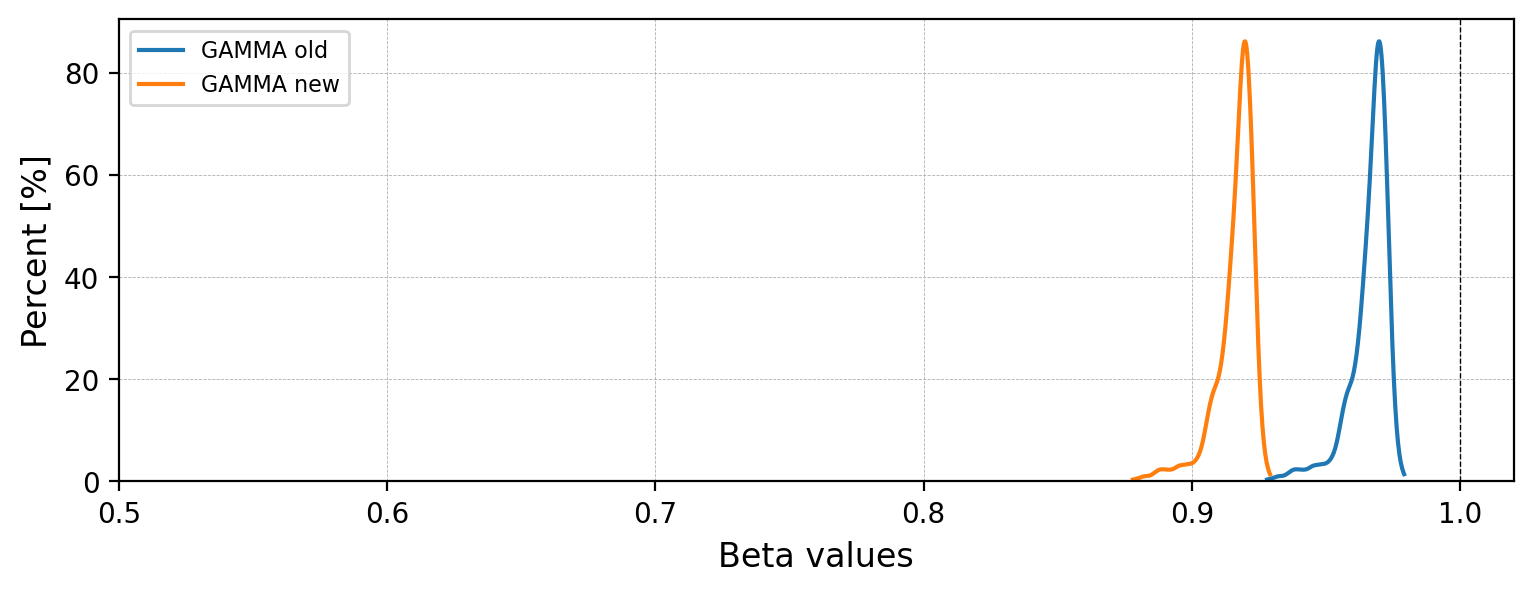

In [25]:
fig = plt.figure(figsize=(9,3),dpi=200)
gs = gridspec.GridSpec(1,1)

# ==========================================================================================================================
ax1 = plt.subplot(gs[0, 0])

sns.kdeplot(GAMMA_old_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label='GAMMA old',
            clip=(np.nanmin(np.array(GAMMA_old_list)), np.nanmax(np.array(GAMMA_old_list))))
sns.kdeplot(GAMMA_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label='GAMMA new',
            clip=(np.nanmin(np.array(GAMMA_list)), np.nanmax(np.array(GAMMA_list))))
ax1.axvline(x=1, color='k', linestyle='--', linewidth=  0.5)

ax1.legend(fontsize=8, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(0.5, 1.02)
ax1.set_ylabel('Percent [%]',fontsize=12)
ax1.set_xlabel('Beta values',fontsize=12)

In [26]:
GAMMA_xr = xr.Dataset(data_vars={
                "GAMMA": (("lat","lon"), GAMMA_update),},
                coords={'lat': lats, 'lon': lons},
                attrs=dict(description=f"Gamma for {product} in the {area} area bounded by longitudes {lon_min} to {lon_max} and box size 5x5."))

GAMMA_xr.GAMMA.attrs["units"] = "dimensionless"
GAMMA_xr.GAMMA.attrs["long_name"] = "Itermittency function between two generic scales"
GAMMA_xr.GAMMA.attrs["origname"] = "Gamma"

In [27]:
dir_out = os.path.join('..','..','output','Gamma',gamma_version,f'ITALY_gamma_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
print(f'Export Data to {dir_out}')
GAMMA_xr.to_netcdf(dir_out)

Export Data to ../../output/Gamma/gamma_v2/ITALY_gamma_IMERG_1dy_2002_2023_npix_2.nc
